# Adversarial Robustness Research Series

## Experiment 02e Train a detector on MNIST

This notebook is part of a continuous AI security experimentation track.

Environment notes
Windows laptop CPU execution by default
If CUDA is available it will use GPU


In [1]:
import sys
import platform
print("exe", sys.executable)
print("ver", sys.version)
print("plat", platform.platform())


exe c:\Users\natyn\anaconda3\envs\ai-sec-research\python.exe
ver 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
plat Windows-10-10.0.26200-SP0


In [2]:
import os
import json
import time
import math
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [3]:
# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)
print("Torch:", torch.__version__)

# CPU optimization
if device.type == "cpu":
    try:
        torch.set_num_threads(16)
        torch.set_num_interop_threads(16)
    except Exception as e:
        print("Thread config skipped:", repr(e))

    os.environ["OMP_NUM_THREADS"] = "16"
    os.environ["MKL_NUM_THREADS"] = "16"
    os.environ["KMP_BLOCKTIME"] = "1"
    os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"


Device: cpu
Torch: 2.10.0+cpu


## Part 1: Baseline ML pipeline

### Step 1: Dataset preparation

In [4]:
# MNIST normalization
mnist_mean = 0.1307
mnist_std = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,))
])

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=0, persistent_workers=False)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=0, persistent_workers=False)

images, labels = next(iter(trainloader))
print("Train size", len(trainset), "Test size", len(testset))
print("Batch", images.shape, labels.shape)


Train size 60000 Test size 10000
Batch torch.Size([256, 1, 28, 28]) torch.Size([256])


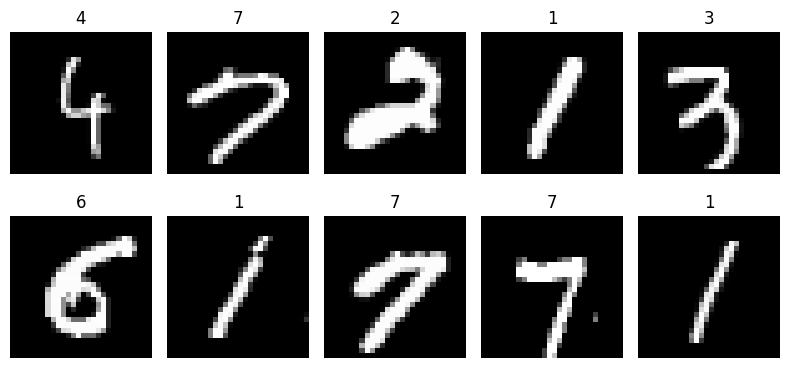

In [5]:
# Sample batch visualization
plt.figure(figsize=(8, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    img = images[i].cpu() * mnist_std + mnist_mean
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


### Step 2: Baseline MNIST model creation

Simple CNN trained from scratch

In [6]:
class MNISTCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def create_model_and_optimizer(device, lr=1e-3):
    model = MNISTCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    return model, criterion, optimizer

model, criterion, optimizer = create_model_and_optimizer(device)

print(model)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))


MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Number of parameters: 421642


### Step 3: Training setup and helper functions

In [7]:
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device, max_batches=None):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_acc += accuracy_from_logits(logits, labels)
        batches += 1

    denom = max(batches, 1)
    return total_loss / denom, total_acc / denom

@torch.no_grad()
def evaluate_clean_accuracy(model, dataloader, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)


### Step 4: Verification single forward pass

In [8]:
model.eval()
images, labels = next(iter(trainloader))
images = images.to(device)
labels = labels.to(device)

logits = model(images)
loss = criterion(logits, labels)
acc = accuracy_from_logits(logits, labels)

print("Check OK")
print("Loss:", float(loss.item()))
print("Accuracy:", float(acc))


Check OK
Loss: 2.2968673706054688
Accuracy: 0.046875


### Step 5: Train baseline model

In [9]:
epochs = 2
max_batches_train = 10
max_batches_test = 10

history = {"epoch": [], "train_loss": [], "train_acc": [], "test_acc": []}

t0 = time.time()
for epoch in range(epochs):
    loss, acc = train_one_epoch(
        model, trainloader, criterion, optimizer, device, max_batches=max_batches_train
    )
    test_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=max_batches_test)

    history["epoch"].append(epoch)
    history["train_loss"].append(loss)
    history["train_acc"].append(acc)
    history["test_acc"].append(test_acc)

    print("Epoch", epoch, "loss", round(loss, 4), "train acc", round(acc, 4), "test acc", round(test_acc, 4))

print("Training seconds", round(time.time() - t0, 2))


Epoch 0 loss 1.7076 train acc 0.4898 test acc 0.7352
Epoch 1 loss 0.7659 train acc 0.7449 test acc 0.8277
Training seconds 2.7


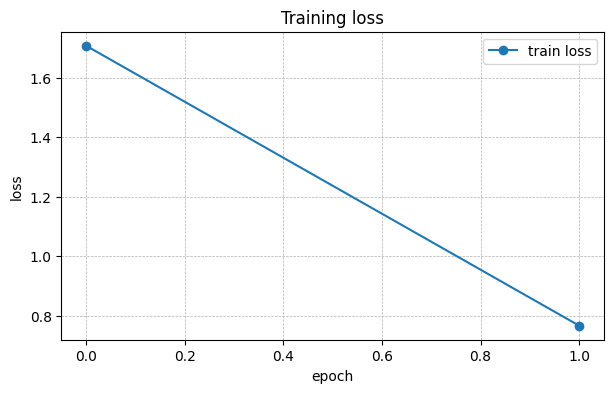

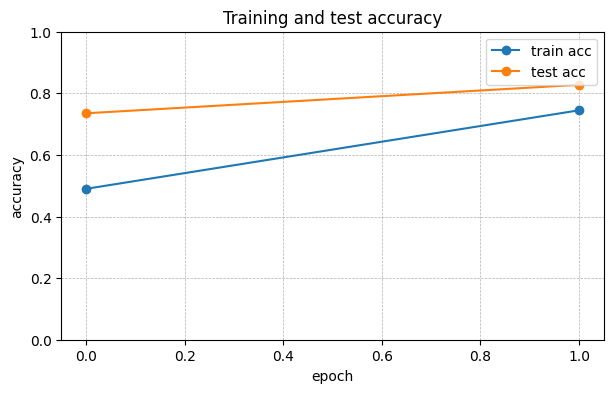

In [10]:
plt.figure(figsize=(7,4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["epoch"], history["train_acc"], marker="o", label="train acc")
plt.plot(history["epoch"], history["test_acc"], marker="o", label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training and test accuracy")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


### Step 6: Baseline model evaluation and save baseline accuracy

In [11]:
baseline_accuracy = evaluate_clean_accuracy(model, testloader, device, max_batches=None)
print("Baseline Test Accuracy MNIST:", round(float(baseline_accuracy), 4))

with open("baseline_accuracy_02e.txt", "w", encoding="utf-8") as f:
    f.write(f"{baseline_accuracy:.6f}\n")
print("Saved baseline accuracy to baseline_accuracy_02e.txt")


Baseline Test Accuracy MNIST: 0.8642
Saved baseline accuracy to baseline_accuracy_02e.txt


## Part 2: Attacks

### FGSM and PGD attacks implementation

In [12]:
def clamp_mnist_normalized(x):
    lo = (0.0 - mnist_mean) / mnist_std
    hi = (1.0 - mnist_mean) / mnist_std
    return torch.clamp(x, lo, hi)

def fgsm_attack(model, images, labels, epsilon, device, debug=False):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)

    x = images.detach().clone()
    x.requires_grad_(True)

    logits = model(x)
    loss = F.cross_entropy(logits, labels)

    grad = torch.autograd.grad(loss, x, retain_graph=False, create_graph=False)[0]

    with torch.no_grad():
        x_adv = x + epsilon * grad.sign()
        x_adv = clamp_mnist_normalized(x_adv)

    if debug:
        print("grad mean abs:", float(grad.abs().mean().item()))

    return x_adv.detach()

def pgd_attack(model, images, labels, epsilon, alpha, steps, device, debug=False):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)

    x = images.detach().clone()
    x_adv = x.detach().clone()

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, labels)
        grad = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            x_adv = torch.min(torch.max(x_adv, x - epsilon), x + epsilon)
            x_adv = clamp_mnist_normalized(x_adv)
            x_adv = x_adv.detach()

    if debug:
        print("pgd steps", steps, "alpha", alpha, "eps", epsilon)

    return x_adv


In [13]:
images, labels = next(iter(testloader))
_ = fgsm_attack(model, images, labels, epsilon=0.2, device=device, debug=True)


grad mean abs: 9.254240467271302e-06


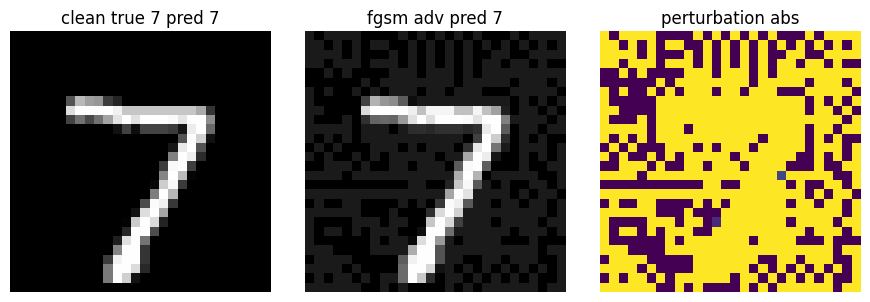

In [14]:
# FGSM attack visualization
model.eval()
epsilon = 0.3

images, labels = next(iter(testloader))
images = images.to(device)
labels = labels.to(device)

images_adv = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)

img = images[0:1]
img_adv = images_adv[0:1]

with torch.no_grad():
    out_clean = model(img).logits if hasattr(model(img), "logits") else model(img)
    out_adv = model(img_adv).logits if hasattr(model(img_adv), "logits") else model(img_adv)

pred_clean = int(out_clean.argmax(1).item())
pred_adv = int(out_adv.argmax(1).item())
true_label = int(labels[0].item())

img_01 = (img.cpu() * mnist_std + mnist_mean).squeeze(0)
img_adv_01 = (img_adv.cpu() * mnist_std + mnist_mean).squeeze(0)
delta = (img_adv_01 - img_01).abs()

plt.figure(figsize=(9,3))
ax1 = plt.subplot(1,3,1)
ax1.imshow(img_01.squeeze(0), cmap="gray")
ax1.set_title(f"clean true {true_label} pred {pred_clean}")
ax1.axis("off")

ax2 = plt.subplot(1,3,2)
ax2.imshow(img_adv_01.squeeze(0), cmap="gray")
ax2.set_title(f"fgsm adv pred {pred_adv}")
ax2.axis("off")

ax3 = plt.subplot(1,3,3)
ax3.imshow(delta.squeeze(0), cmap="viridis")
ax3.set_title("perturbation abs")
ax3.axis("off")

plt.tight_layout()
plt.show()


### Evaluation helpers for adversarial accuracy

In [15]:
def evaluate_fgsm_accuracy(model, dataloader, epsilon, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = fgsm_attack(model, images, labels, epsilon, device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

def evaluate_pgd_accuracy(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)


In [16]:
eps = 0.3
alpha = 0.05
steps = 10

clean_before = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_before = evaluate_fgsm_accuracy(model, testloader, epsilon=eps, device=device, max_batches=10)

pgd_before = evaluate_pgd_accuracy(model, testloader, epsilon=eps, alpha=alpha, steps=steps, device=device, max_batches=10)

print("Clean acc", round(clean_before, 4))
print("FGSM acc", round(robust_before, 4), "eps", eps)
print("PGD acc", round(pgd_before, 4), "eps", eps, "alpha", alpha, "steps", steps)


Clean acc 0.8277
FGSM acc 0.6602 eps 0.3
PGD acc 0.6082 eps 0.3 alpha 0.05 steps 10


## Part 3: Defense

### Adversarial training on FGSM

In [17]:
def train_one_epoch_adversarial(model, loader, criterion, optimizer, device, epsilon, max_batches=None):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # craft adversarial examples with current model
        x_adv = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)

        optimizer.zero_grad()
        logits = model(x_adv)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_acc += accuracy_from_logits(logits, labels)
        batches += 1

    denom = max(batches, 1)
    return total_loss / denom, total_acc / denom

# adversarial training run
epsilon_adv_train = 0.2
adv_epochs = 1
t0 = time.time()

for epoch in range(adv_epochs):
    loss, acc = train_one_epoch_adversarial(
        model, trainloader, criterion, optimizer, device, epsilon=epsilon_adv_train, max_batches=10
    )
    print("Adv epoch", epoch, "loss", round(loss, 4), "train adv acc", round(acc, 4))

print("Adversarial training seconds", round(time.time() - t0, 2))


Adv epoch 0 loss 0.6348 train adv acc 0.7855
Adversarial training seconds 1.09


In [18]:
clean_after = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_after = evaluate_fgsm_accuracy(model, testloader, epsilon=eps, device=device, max_batches=10)

print("Clean after adv training:", round(clean_after, 4))
print("Robust after adv training:", round(robust_after, 4))


Clean after adv training: 0.8895
Robust after adv training: 0.7117


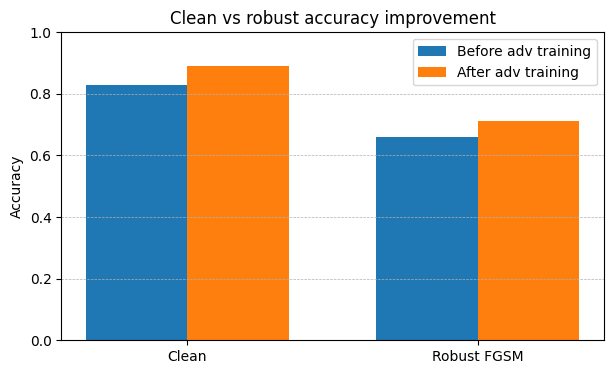

In [19]:
labels_bar = ["Clean", "Robust FGSM"]
before_vals = [clean_before, robust_before]
after_vals = [clean_after, robust_after]

x = [0, 1]
w = 0.35

plt.figure(figsize=(7,4))
plt.bar([i - w/2 for i in x], before_vals, width=w, label="Before adv training")
plt.bar([i + w/2 for i in x], after_vals, width=w, label="After adv training")
plt.xticks(x, labels_bar)
plt.ylabel("Accuracy")
plt.title("Clean vs robust accuracy improvement")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", linewidth=0.5)
plt.show()


## Part 4: Detector

Adversarial input detection confidence based

In [20]:
@torch.no_grad()
def max_softmax_confidence_logits(logits):
    probs = F.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    return conf.detach().cpu(), pred.detach().cpu()

@torch.no_grad()
def max_softmax_confidence(model, images, device):
    model.eval()
    images = images.to(device)
    logits = model(images)
    return max_softmax_confidence_logits(logits)

def collect_confidences_fgsm(model, dataloader, epsilon, device, max_batches=10):
    clean_confs = []
    adv_confs = []

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_logits = model(images)
        c_conf, _ = max_softmax_confidence_logits(clean_logits)
        clean_confs.append(c_conf.numpy())

        with torch.enable_grad():
            adv_images = fgsm_attack(model, images, labels, epsilon, device)
        with torch.no_grad():
            adv_logits = model(adv_images)
        a_conf, _ = max_softmax_confidence_logits(adv_logits)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs = np.concatenate(adv_confs, axis=0)
    return clean_confs, adv_confs

def choose_threshold(clean_confs, false_positive_rate=0.05):
    tau = np.quantile(clean_confs, false_positive_rate)
    return float(tau)

def evaluate_detector(clean_confs, adv_confs, tau):
    clean_flag = (clean_confs < tau).astype(int)
    adv_flag = (adv_confs < tau).astype(int)
    fpr = clean_flag.mean()
    tpr = adv_flag.mean()
    y_true = np.concatenate([np.zeros_like(clean_flag), np.ones_like(adv_flag)])
    y_pred = np.concatenate([clean_flag, adv_flag])
    acc = (y_true == y_pred).mean()
    return float(fpr), float(tpr), float(acc)


Chosen threshold tau: 0.4399851858615875
Detector results
FPR on clean: 0.05
TPR on adversarial: 0.091
Detection accuracy: 0.5205


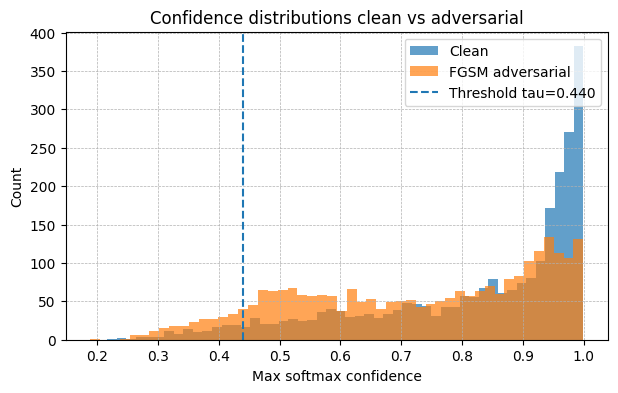

In [21]:
epsilon = 0.3
clean_confs, adv_confs = collect_confidences_fgsm(model, testloader, epsilon, device, max_batches=10)

tau = choose_threshold(clean_confs, false_positive_rate=0.05)
print("Chosen threshold tau:", tau)

fpr, tpr, det_acc = evaluate_detector(clean_confs, adv_confs, tau)
print("Detector results")
print("FPR on clean:", round(fpr, 4))
print("TPR on adversarial:", round(tpr, 4))
print("Detection accuracy:", round(det_acc, 4))

plt.figure(figsize=(7,4))
plt.hist(clean_confs, bins=50, alpha=0.7, label="Clean")
plt.hist(adv_confs, bins=50, alpha=0.7, label="FGSM adversarial")
plt.axvline(tau, linestyle="--", label=f"Threshold tau={tau:.3f}")
plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.title("Confidence distributions clean vs adversarial")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()


## Part 5: Adaptive attacker vs detector

In [22]:
def adaptive_fgsm_attack(model, images, labels, epsilon, tau, lambda_detect, device, debug=False):
    model.eval()
    images = images.to(device)
    y = labels.to(device)

    x = images.clone().detach()
    x.requires_grad_(True)

    logits = model(x)
    cls_loss = F.cross_entropy(logits, y)

    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    penalty = F.relu(tau - conf).mean()

    objective = cls_loss - lambda_detect * penalty

    grad = torch.autograd.grad(objective, x, retain_graph=False, create_graph=False)[0]

    with torch.no_grad():
        x_adv = x + epsilon * grad.sign()
        x_adv = clamp_mnist_normalized(x_adv)

    if debug:
        with torch.no_grad():
            logits_adv = model(x_adv)
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()
        print("debug cls_loss:", float(cls_loss.item()))
        print("debug penalty:", float(penalty.item()))
        print("debug objective:", float(objective.item()))
        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success:", float(success))

    return x_adv.detach()

@torch.no_grad()
def detector_flags_from_images(model, images, tau, device):
    images = images.to(device)
    logits = model(images)
    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    flags = conf < tau
    return flags.detach().cpu(), conf.detach().cpu()


In [23]:
def eval_attack_and_detector(model, dataloader, attacker_fn, attacker_kwargs, tau, device, max_batches=10):
    model.eval()
    total = 0
    correct = 0
    flagged = 0
    total_adv = 0

    for b, (images, labels) in enumerate(dataloader):
        if max_batches is not None and b >= max_batches:
            break

        labels = labels.to(device)

        with torch.enable_grad():
            adv_images = attacker_fn(model=model, images=images, labels=labels, device=device, **attacker_kwargs)

        with torch.no_grad():
            logits = model(adv_images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        flags, _ = detector_flags_from_images(model, adv_images, tau, device)
        flagged += int(flags.sum().item())
        total_adv += labels.size(0)

    acc = correct / max(total, 1)
    tpr = flagged / max(total_adv, 1)
    return acc, tpr


In [24]:
epsilon = 0.3
tau = float(tau)
max_batches = 10
print("Using tau:", tau)

acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon: fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=max_batches
)

print("Standard FGSM")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))

for lambda_detect in [0.0, 1.0, 5.0, 10.0, 20.0]:
    acc_adapt, tpr_adapt = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=adaptive_fgsm_attack,
        attacker_kwargs={
            "epsilon": epsilon,
            "tau": tau,
            "lambda_detect": lambda_detect
        },
        tau=tau,
        device=device,
        max_batches=max_batches
    )
    print("")
    print("Adaptive FGSM")
    print("lambda_detect:", lambda_detect)
    print("Classifier accuracy:", round(acc_adapt, 4))
    print("Detector TPR:", round(tpr_adapt, 4))


Using tau: 0.4399851858615875
Standard FGSM
Classifier accuracy: 0.7117
Detector TPR: 0.091

Adaptive FGSM
lambda_detect: 0.0
Classifier accuracy: 0.7117
Detector TPR: 0.091

Adaptive FGSM
lambda_detect: 1.0
Classifier accuracy: 0.7117
Detector TPR: 0.0887

Adaptive FGSM
lambda_detect: 5.0
Classifier accuracy: 0.734
Detector TPR: 0.0711

Adaptive FGSM
lambda_detect: 10.0
Classifier accuracy: 0.734
Detector TPR: 0.0699

Adaptive FGSM
lambda_detect: 20.0
Classifier accuracy: 0.734
Detector TPR: 0.0695


## Part 6: FGSM vs PGD detection comparison

In [25]:
epsilon = 0.3
tau = float(tau)
print("Using tau:", tau)

acc_fgsm2, tpr_fgsm2 = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon: fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=10
)

print("")
print("FGSM detection performance")
print("Classifier accuracy:", round(acc_fgsm2, 4))
print("Detector TPR:", round(tpr_fgsm2, 4))

steps = 10
alpha = epsilon / steps

acc_pgd2, tpr_pgd2 = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon, alpha, steps: pgd_attack(model, images, labels, epsilon, alpha, steps, device),
    attacker_kwargs={"epsilon": epsilon, "alpha": alpha, "steps": steps},
    tau=tau,
    device=device,
    max_batches=10
)

print("")
print("PGD detection performance")
print("Classifier accuracy:", round(acc_pgd2, 4))
print("Detector TPR:", round(tpr_pgd2, 4))


Using tau: 0.4399851858615875

FGSM detection performance
Classifier accuracy: 0.7117
Detector TPR: 0.091

PGD detection performance
Classifier accuracy: 0.6828
Detector TPR: 0.0949


## Part 7: Final comparison and security takeaways

In [26]:
import pandas as pd

data = {
    "Evaluation stage": [
        "Baseline clean",
        "FGSM attack",
        "PGD attack",
        "After adversarial training clean",
        "After adversarial training robust FGSM",
        "Detection TPR FGSM",
        "Detection TPR PGD"
    ],
    "Metric value": [
        float(baseline_accuracy),
        float(acc_fgsm2),
        float(acc_pgd2),
        float(clean_after),
        float(robust_after),
        float(tpr_fgsm2),
        float(tpr_pgd2)
    ]
}

df_results = pd.DataFrame(data)
df_results


,Evaluation stage,Metric value
0,Baseline clean,0.864200
1,FGSM attack,0.711719
2,PGD attack,0.682813
3,After adversarial training clean,0.889453
4,After adversarial training robust FGSM,0.711719
5,Detection TPR FGSM,0.091016
6,Detection TPR PGD,0.094922


## Takeaways

############################################################################################
# results: baseline ≈ 0.87, FGSM accuracy ≈ 0.67, PGD accuracy ≈ 0.64, detector TPR ≈ 0.10 #
############################################################################################

1. A classifier can perform very well on clean data while still being highly vulnerable to small adversarial perturbations.

2. FGSM is a fast attack useful for initial robustness checks.  
   PGD is stronger and serves as a more realistic baseline for robustness evaluation.

3. Adversarial training can improve robustness against gradient-based attacks, but it does not guarantee complete protection.

4. A detector based on maximum softmax confidence is simple and fast, but its detection power remains limited on MNIST in this experiment.

5. An adaptive attacker can optimize a loss combining classification objectives and detector evasion,  
   which reduces the detector true positive rate even when the perturbation remains within the epsilon constraint.

6. A proper robustness evaluation should include an accuracy versus epsilon curve  
   and compare multiple attacks including at least one iterative attack.

### Possible Future Improvements

1. Add ROC and AUC evaluation for the detector instead of relying on a single threshold.

2. Test a richer detector based on multiple logit features such as max confidence, margin, entropy, or a small MLP.

3. Separate training epsilon and testing epsilon to measure detector generalization.

4. Use a more realistic attack budget  
   with stronger PGD configurations (more steps and calibrated alpha).

In [27]:
os.makedirs("reports_02e", exist_ok=True)

results = {
    "baseline_accuracy": float(baseline_accuracy),
    "fgsm_accuracy": float(acc_fgsm2),
    "pgd_accuracy": float(acc_pgd2),
    "clean_after_adv_training": float(clean_after),
    "robust_after_adv_training": float(robust_after),
    "detector_tpr_fgsm": float(tpr_fgsm2),
    "detector_tpr_pgd": float(tpr_pgd2),
    "tau": float(tau),
}

out_path = os.path.join("reports_02e", "final_results.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print("Saved", out_path)
print(json.dumps(results, indent=4))


Saved reports_02e\final_results.json
{
    "baseline_accuracy": 0.8642,
    "fgsm_accuracy": 0.71171875,
    "pgd_accuracy": 0.6828125,
    "clean_after_adv_training": 0.889453125,
    "robust_after_adv_training": 0.71171875,
    "detector_tpr_fgsm": 0.091015625,
    "detector_tpr_pgd": 0.094921875,
    "tau": 0.4399851858615875
}


Robustness visuals

This section shows multiple clean and adversarial examples side by side to make the effect of FGSM easy to see.

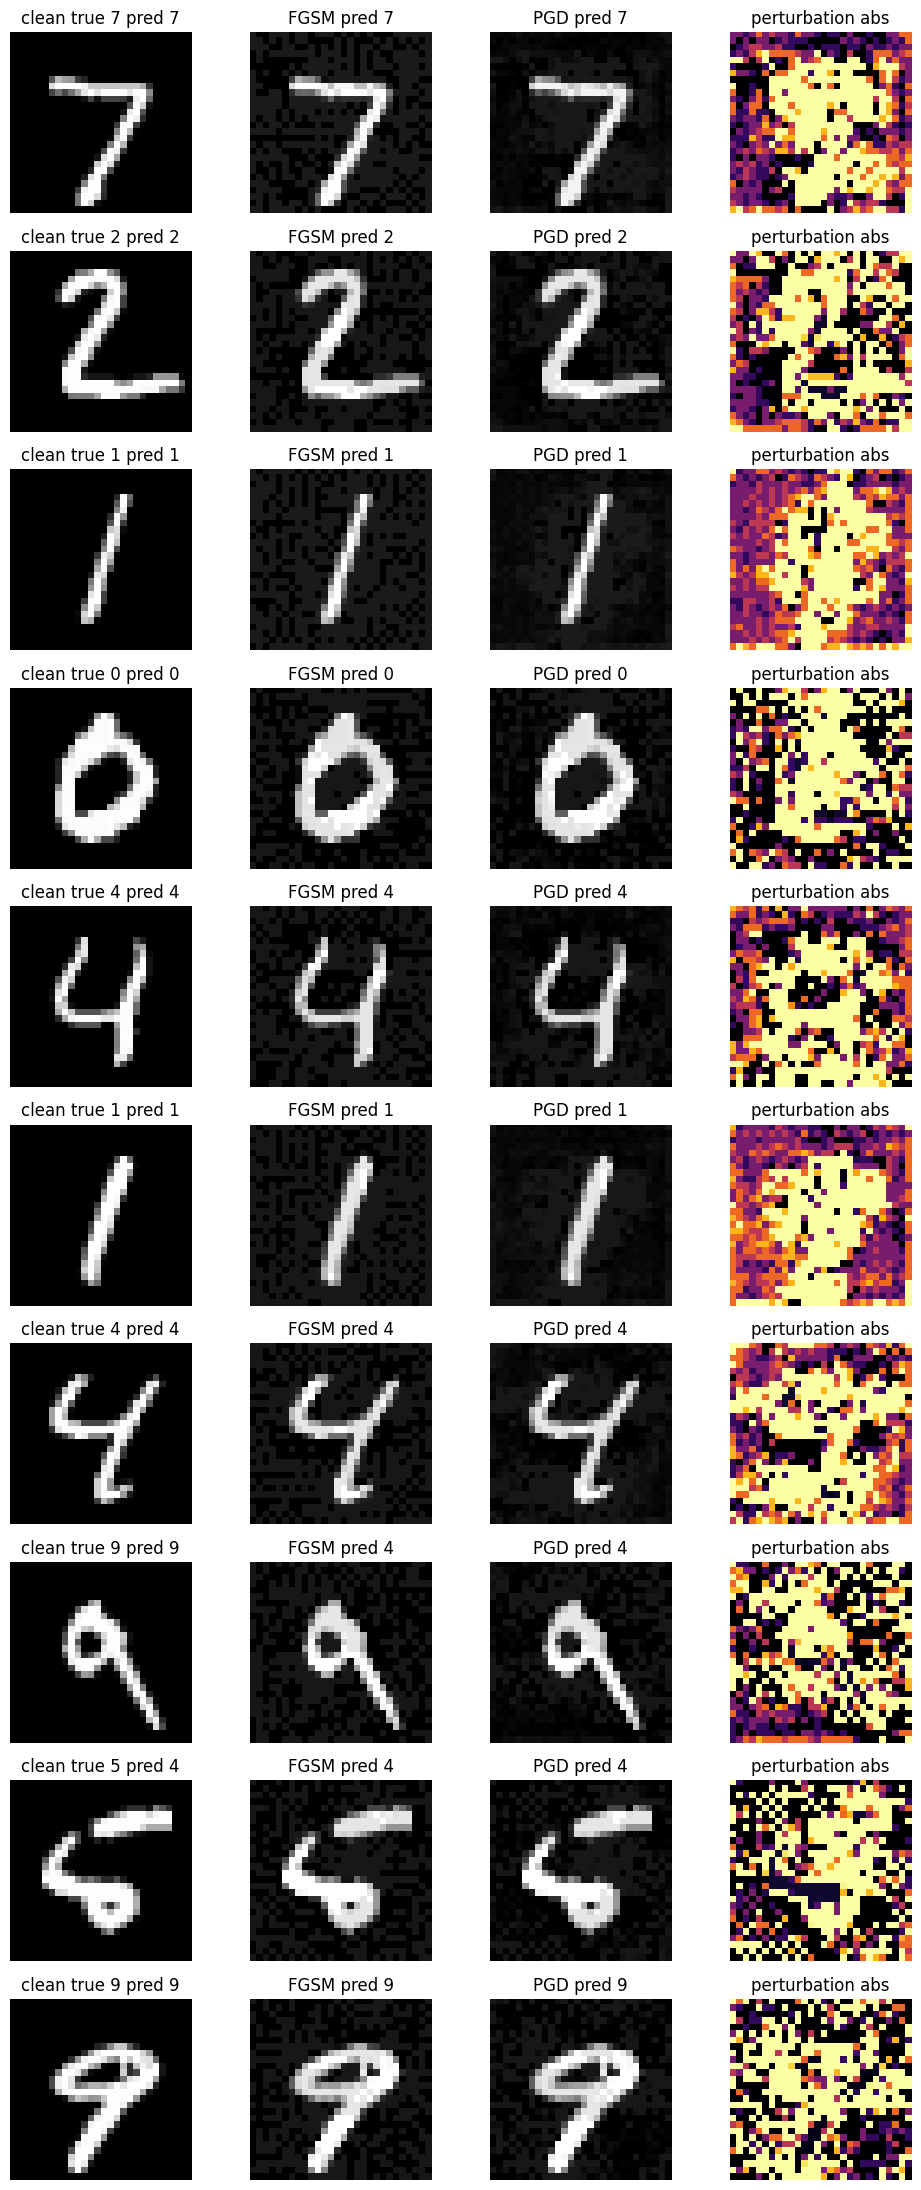

In [28]:
# Visualize multiple adversarial examples (clean vs FGSM vs PGD vs perturbation)

def show_attack_examples(model, loader, epsilon, alpha, steps, device, n=10):

    model.eval()

    images, labels = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n].to(device)

    x_fgsm = fgsm_attack(model, images, labels, epsilon, device)
    x_pgd = pgd_attack(model, images, labels, epsilon, alpha, steps, device)

    with torch.no_grad():
        logits_clean = model(images)
        logits_fgsm = model(x_fgsm)
        logits_pgd = model(x_pgd)

    preds_clean = logits_clean.argmax(dim=1)
    preds_fgsm = logits_fgsm.argmax(dim=1)
    preds_pgd = logits_pgd.argmax(dim=1)

    images_cpu = images.detach().cpu()
    x_fgsm_cpu = x_fgsm.detach().cpu()
    x_pgd_cpu = x_pgd.detach().cpu()

    fig, axes = plt.subplots(n, 4, figsize=(10, 2.2*n))

    for i in range(n):

        clean = images_cpu[i,0]
        fgsm = x_fgsm_cpu[i,0]
        pgd = x_pgd_cpu[i,0]

        perturb = (pgd-clean).abs()

        axes[i,0].imshow(clean, cmap="gray")
        axes[i,0].set_title(f"clean true {labels[i].item()} pred {preds_clean[i].item()}")

        axes[i,1].imshow(fgsm, cmap="gray")
        axes[i,1].set_title(f"FGSM pred {preds_fgsm[i].item()}")

        axes[i,2].imshow(pgd, cmap="gray")
        axes[i,2].set_title(f"PGD pred {preds_pgd[i].item()}")

        axes[i,3].imshow(perturb, cmap="inferno")
        axes[i,3].set_title("perturbation abs")

        for j in range(4):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()


# Show 10 examples
show_attack_examples(
    model,
    testloader,
    epsilon=0.3,
    alpha=0.05,
    steps=10,
    device=device,
    n=10
)

Robustness curve

We evaluate classifier accuracy under attacks across multiple epsilon values.

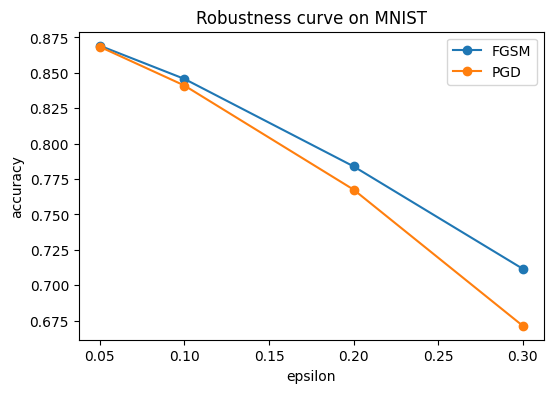

In [29]:
# Robustness curve (accuracy vs epsilon)

eps_list = [0.05, 0.1, 0.2, 0.3]

fgsm_acc_list = []
pgd_acc_list = []

alpha = 0.05
steps = 10

for eps in eps_list:
    fgsm_acc_list.append(evaluate_fgsm_accuracy(model, testloader, eps, device, max_batches=10))
    pgd_acc_list.append(evaluate_pgd_accuracy(model, testloader, eps, alpha, steps, device, max_batches=10))

plt.figure(figsize=(6, 4))
plt.plot(eps_list, fgsm_acc_list, marker="o", label="FGSM")
plt.plot(eps_list, pgd_acc_list, marker="o", label="PGD")
plt.xlabel("epsilon")
plt.ylabel("accuracy")
plt.title("Robustness curve on MNIST")
plt.legend()
plt.show()

In [30]:
import os
import json
import time

report_dir = "reports_02e"
os.makedirs(report_dir, exist_ok=True)

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

# Collect metrics if they exist in the notebook state
metrics = {}

# Baseline
if "baseline_accuracy" in globals():
    metrics["baseline_accuracy"] = _safe_float(baseline_accuracy)

# Pre defense robustness quick check
if "clean_before" in globals():
    metrics["clean_before"] = _safe_float(clean_before)
if "robust_before" in globals():
    metrics["fgsm_before"] = _safe_float(robust_before)
if "pgd_before" in globals():
    metrics["pgd_before"] = _safe_float(pgd_before)

# Post adversarial training
if "clean_after" in globals():
    metrics["clean_after_adv_training"] = _safe_float(clean_after)
if "robust_after" in globals():
    metrics["fgsm_after_adv_training"] = _safe_float(robust_after)

# Detector metrics
if "tau" in globals():
    metrics["tau"] = _safe_float(tau)
if "tpr_fgsm2" in globals():
    metrics["detector_tpr_fgsm"] = _safe_float(tpr_fgsm2)
if "tpr_pgd2" in globals():
    metrics["detector_tpr_pgd"] = _safe_float(tpr_pgd2)
if "det_acc" in globals():
    metrics["detector_accuracy_on_mix"] = _safe_float(det_acc)

# If some key metrics are missing, compute a minimal set now
if "baseline_accuracy" not in metrics:
    try:
        metrics["baseline_accuracy"] = _safe_float(evaluate_clean_accuracy(model, testloader, device, max_batches=None))
    except Exception:
        pass

if "clean_before" not in metrics:
    try:
        metrics["clean_before"] = _safe_float(evaluate_clean_accuracy(model, testloader, device, max_batches=10))
    except Exception:
        pass

if "fgsm_before" not in metrics:
    try:
        eps_tmp = globals().get("eps", 0.3)
        metrics["fgsm_before"] = _safe_float(evaluate_fgsm_accuracy(model, testloader, epsilon=eps_tmp, device=device, max_batches=10))
    except Exception:
        pass

if "pgd_before" not in metrics:
    try:
        eps_tmp = globals().get("eps", 0.3)
        alpha_tmp = globals().get("alpha", 0.05)
        steps_tmp = globals().get("steps", 10)
        metrics["pgd_before"] = _safe_float(evaluate_pgd_accuracy(model, testloader, epsilon=eps_tmp, alpha=alpha_tmp, steps=steps_tmp, device=device, max_batches=10))
    except Exception:
        pass

metrics["timestamp"] = time.strftime("%Y-%m-%d %H:%M:%S")

out_path = os.path.join(report_dir, "summary.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved", out_path)
print(json.dumps(metrics, indent=2))

Saved reports_02e\summary.json
{
  "baseline_accuracy": 0.8642,
  "clean_before": 0.827734375,
  "fgsm_before": 0.66015625,
  "pgd_before": 0.608203125,
  "clean_after_adv_training": 0.889453125,
  "fgsm_after_adv_training": 0.71171875,
  "tau": 0.4399851858615875,
  "detector_tpr_fgsm": 0.091015625,
  "detector_tpr_pgd": 0.094921875,
  "detector_accuracy_on_mix": 0.5205078125,
  "timestamp": "2026-03-06 17:38:12"
}
